<a href="https://colab.research.google.com/github/syrashid/rl-lunar-lander/blob/main/reinforce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Update apt, install dependencies, install**

In [1]:
!apt-get -y update
!apt-get -y install swig cmake ffmpeg
!pip -q install "gymnasium[box2d]" imageio imageio-ffmpeg

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,684 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,608 kB]
Get:14 http://ar

**Set up Lunar Lander env**

In [2]:
import os
import gymnasium as gym

# LunarLander is usually v3, but this fallback keeps you unblocked.
def make_lander_env():
    for env_id in ["LunarLander-v3", "LunarLander-v2"]:
        try:
            return gym.make(env_id, continuous=False), env_id
            break;
        except Exception:
            pass
    raise RuntimeError("Could not create LunarLander env (tried v3/v2).")

env, ENV_ID = make_lander_env()


print("Using env:", ENV_ID)

env.observation_space

env.action_space

env.observation_space.shape

env.action_space.n

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)
print("Observation Space Shape:", env.observation_space.shape)
print("Action Space n:", env.action_space.n)

Using env: LunarLander-v3
Observation Space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action Space: Discrete(4)
Observation Space Shape: (8,)
Action Space n: 4


**Policy NN**

In [3]:
import torch
import torch.nn as nn

class PolicyNet(nn.Module):
    def __init__(self, obs_dim: int = 8, n_actions: int = 4, hidden_size: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),  # logits (raw scores), NOT softmax
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Returns action logits.
        - If x is shape [obs_dim], returns shape [n_actions]
        - If x is shape [batch, obs_dim], returns shape [batch, n_actions]
        """
        if x.dim() == 1:
            x = x.unsqueeze(0)          # [1, obs_dim]
            logits = self.net(x)        # [1, n_actions]
            return logits.squeeze(0)    # [n_actions]
        return self.net(x)              # [batch, n_actions]


**Action Selection Helper**

In [4]:
import numpy as np
from torch.distributions import Categorical

def select_action(policy: torch.nn.Module, obs: np.ndarray, device: torch.device | str = "cpu"):
    """
    Given a single observation (shape: [8]), returns:
      - action: Python int in {0,1,2,3}
      - log_prob: torch scalar tensor (keep as tensor for REINFORCE update)
      - entropy: torch scalar tensor (optional, useful later for exploration bonus)
    """
    # 1) Convert obs -> tensor
    obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)

    # 2) Forward pass -> logits (shape [4])
    logits = policy(obs_t)

    # 3) Distribution from logits (softmax handled internally)
    dist = Categorical(logits=logits)

    # 4) Sample action + log_prob
    action_t = dist.sample()              # tensor scalar (0..3)
    log_prob = dist.log_prob(action_t)    # tensor scalar
    entropy = dist.entropy()              # tensor scalar

    # 5) Return action as int (env.step expects int)
    action = int(action_t.item())
    return action, log_prob, entropy


**Run episode**

In [5]:
from typing import List, Tuple
import numpy as np
import torch

def run_episode(env, policy: torch.nn.Module, device: torch.device | str = "cpu"
               ) -> Tuple[List[torch.Tensor], List[float], List[torch.Tensor]]:
    """
    Runs ONE full episode using the current policy.

    Returns:
      - log_probs: list of torch scalar tensors (one per step)
      - rewards:   list of floats (one per step)
      - entropies: list of torch scalar tensors (one per step)  [optional but handy later]
    """
    obs, info = env.reset()
    done = False

    log_probs: List[torch.Tensor] = []
    rewards: List[float] = []
    entropies: List[torch.Tensor] = []

    while not done:
        action, log_prob, entropy = select_action(policy, obs, device=device)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)

        log_probs.append(log_prob)
        rewards.append(float(reward))
        entropies.append(entropy)

        obs = next_obs

    return log_probs, rewards, entropies


**Transform Rewards & Loss**

In [13]:
from typing import List
import torch

def compute_returns(rewards: List[float], gamma: float = 0.99, device: torch.device | str = "cpu") -> torch.Tensor:
    """
    Compute reward-to-go returns for a single episode.

    rewards: [r0, r1, ..., rT]
    returns: [G0, G1, ..., GT] where Gt = r_t + gamma*r_{t+1} + gamma^2*r_{t+2} + ...

    Returns a 1D torch tensor of shape [T+1] on the given device.
    """
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = float(r) + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=device)

def reinforce_loss(log_probs: List[torch.Tensor], returns: torch.Tensor, normalize: bool = True) -> torch.Tensor:
    """
    REINFORCE loss for one episode (or you can sum across episodes later).

    log_probs: list of torch scalar tensors (length T+1)
    returns: torch tensor shape [T+1]
    """
    log_probs_t = torch.stack(log_probs)  # shape [T+1]

    if normalize:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    loss = -(log_probs_t * returns).sum()
    return loss

def reinforce_loss_with_entropy(
    log_probs: list[torch.Tensor],
    returns: torch.Tensor,
    entropies: list[torch.Tensor],
    beta: float = 0.01,
    normalize: bool = True
) -> torch.Tensor:
    log_probs_t = torch.stack(log_probs)      # [T]
    entropies_t = torch.stack(entropies)      # [T]

    if normalize:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    policy_loss = -(log_probs_t * returns).sum()
    entropy_bonus = entropies_t.sum()         # higher is more exploratory

    # subtract because we MINIMIZE loss but want to MAXIMIZE entropy
    return policy_loss - beta * entropy_bonus

**Train REINFORCE Policy**

In [47]:
import torch

def train_reinforce(
    env,
    policy: torch.nn.Module,
    num_episodes: int = 1000,
    batch_size: int = 10,
    gamma: float = 0.99,
    lr: float = 1e-3,
    beta: float = 1e-2,
    device: torch.device | str = "cpu",
    normalize_returns: bool = True,
    grad_clip_norm: float | None = None,
    print_every: int = 10,
):
    """
    REINFORCE training wrapper (on-policy).
    - Runs episodes, builds returns, builds loss
    - Does one optimizer update every `batch_size` episodes
    - Prints simple progress

    Returns:
      - returns_history: list of episode returns (sum of rewards)
    """
    policy = policy.to(device)
    policy.train()

    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    returns_history: list[float] = []
    batch_losses: list[torch.Tensor] = []

    for ep in range(1, num_episodes + 1):
        # 1) Collect one episode (log_probs + rewards)
        log_probs, rewards, entropies = run_episode(env, policy, device=device)

        # 2) Book-keeping: total episode return
        ep_return = float(sum(rewards))
        returns_history.append(ep_return)

        # 3) Compute returns (reward-to-go)
        returns_t = compute_returns(rewards, gamma=gamma, device=device)

        # 4) Compute REINFORCE loss for this episode
        loss = reinforce_loss_with_entropy(log_probs, returns_t, entropies, beta, normalize_returns)
        batch_losses.append(loss)

        # 5) Update policy every batch_size episodes
        if ep % batch_size == 0:
            optimizer.zero_grad()
            batch_loss = torch.stack(batch_losses).mean()
            batch_loss.backward()

            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip_norm)

            optimizer.step()
            batch_losses.clear()

        # 6) Progress prints
        if ep % print_every == 0:
            recent = returns_history[-print_every:]
            avg_recent = sum(recent) / len(recent)
            print(f"Episode {ep:5d} | avg return (last {print_every}) = {avg_recent:8.2f}")

    # If we ended mid-batch, do one last update
    if len(batch_losses) > 0:
        optimizer.zero_grad()
        batch_loss = torch.stack(batch_losses).mean()
        batch_loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip_norm)

        optimizer.step()
        batch_losses.clear()

    return returns_history



**Do the thing**

Using device: cpu
Episode   100 | avg return (last 100) =  -158.94
Episode   200 | avg return (last 100) =  -174.87
Episode   300 | avg return (last 100) =  -172.59
Episode   400 | avg return (last 100) =  -167.12
Episode   500 | avg return (last 100) =  -176.92
Episode   600 | avg return (last 100) =  -162.71
Episode   700 | avg return (last 100) =  -154.93
Episode   800 | avg return (last 100) =  -167.65
Episode   900 | avg return (last 100) =  -175.11
Episode  1000 | avg return (last 100) =  -169.62
Episode  1100 | avg return (last 100) =  -183.30
Episode  1200 | avg return (last 100) =  -182.51
Episode  1300 | avg return (last 100) =  -165.19
Episode  1400 | avg return (last 100) =  -193.19
Episode  1500 | avg return (last 100) =  -156.23
Episode  1600 | avg return (last 100) =  -177.46
Episode  1700 | avg return (last 100) =  -166.56
Episode  1800 | avg return (last 100) =  -178.42
Episode  1900 | avg return (last 100) =  -160.68
Episode  2000 | avg return (last 100) =  -164.69
Ep

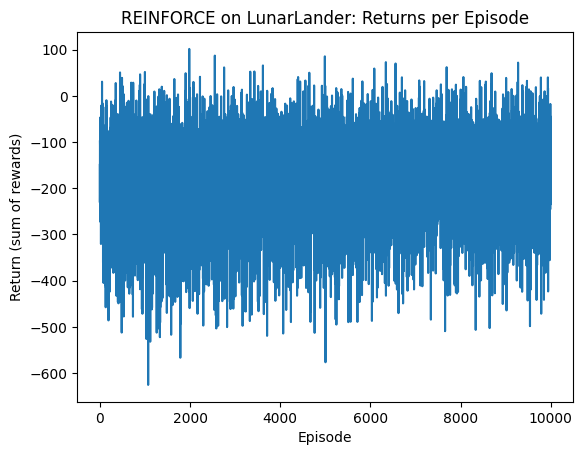

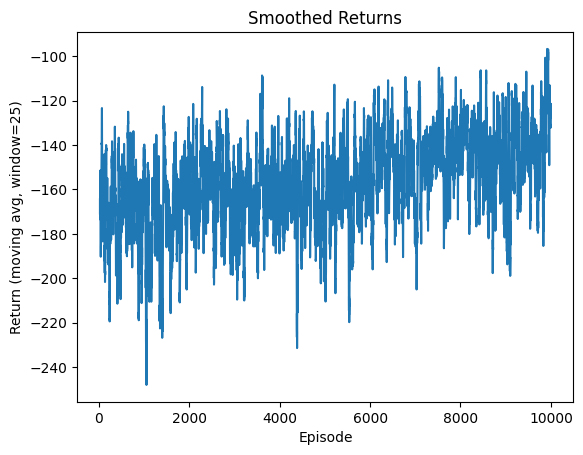

In [49]:
import torch
import matplotlib.pyplot as plt

# 1) Pick device (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 2) Create a fresh policy
policy = PolicyNet(obs_dim=env.observation_space.shape[0], n_actions=env.action_space.n, hidden_size=128)

# 3) Train with REINFORCE
returns_history = train_reinforce(
    env=env,
    policy=policy,
    num_episodes=10000,
    batch_size=100,
    gamma=0.99,
    lr=1e-4,
    beta=1e-3,
    device=device,
    normalize_returns=True,
    grad_clip_norm=1.0,     # helps stability; set to None to disable
    print_every=100,
)

# 4) Plot returns by episode
plt.figure()
plt.plot(returns_history)
plt.xlabel("Episode")
plt.ylabel("Return (sum of rewards)")
plt.title("REINFORCE on LunarLander: Returns per Episode")
plt.show()

# (Optional) Plot a simple moving average for readability
window = 25
if len(returns_history) >= window:
    smoothed = [
        sum(returns_history[i-window:i]) / window
        for i in range(window, len(returns_history) + 1)
    ]
    plt.figure()
    plt.plot(range(window-1, len(returns_history)), smoothed)
    plt.xlabel("Episode")
    plt.ylabel(f"Return (moving avg, window={window})")
    plt.title("Smoothed Returns")
    plt.show()


TODO: Explore subtracting the baseline for additional variance reduction

**Select Action Helper**

In [50]:
import torch

def select_action_greedy(policy: torch.nn.Module, obs, device="cpu") -> int:
    policy.eval()
    with torch.no_grad():
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
        logits = policy(obs_t)                 # shape [4]
        action = int(torch.argmax(logits).item())
    return action


**Watch an Episode**

In [60]:
import os
import glob
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
import base64

# Create a NEW env that can render frames (important!)
video_dir = "videos"
os.makedirs(video_dir, exist_ok=True)

# (Optional) clean old videos
for f in glob.glob(os.path.join(video_dir, "*.mp4")):
    os.remove(f)

eval_env = gym.make(ENV_ID, continuous=False, render_mode="rgb_array")
eval_env = RecordVideo(
    eval_env,
    video_folder=video_dir,
    episode_trigger=lambda episode_id: True,   # record every episode we run
    name_prefix="reinforce_eval",
)

obs, info = eval_env.reset()
done = False
total_reward = 0.0

while not done:
    action = select_action_greedy(policy, obs, device=device)  # use your trained policy
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
    total_reward += float(reward)

eval_env.close()
print("Eval episode return:", total_reward)

# Find the recorded mp4 and display it
mp4_files = sorted(glob.glob(os.path.join(video_dir, "*.mp4")))
assert len(mp4_files) > 0, "No video file found. Did RecordVideo create an mp4?"
mp4_path = mp4_files[-1]
print("Video saved to:", mp4_path)

with open(mp4_path, "rb") as f:
    video_bytes = f.read()
video_b64 = base64.b64encode(video_bytes).decode("ascii")
display(HTML(f"""
<video width="640" height="480" controls>
  <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>
"""))


Eval episode return: -812.4293019115711
Video saved to: videos/reinforce_eval-episode-0.mp4
